In [ ]:
import pandas as pd
import numpy as np

In [ ]:
url="https://raw.githubusercontent.com/JUAN-32/Parcial4_JuanCortez_2500952022/refs/heads/main/raw/clave_I_agrupacion.csv"
df= pd.read_csv(url)
df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,I-R0155,41,1855,8.60,192.15,8.53,1,52
1,I-R0116,33,994,6.04,62.84,9.40,1,18
2,I-R0233,43,807,2.94,73.22,4.81,3,12
3,I-R0167,52,1528,9.44,157.53,7.15,12,54
4,I-R0108,27,1169,6.04,92.08,7.97,1,7


In [ ]:
print("Primeras filas:")
print(df.head())

print("\nDimensiones:")
print(df.shape)

print("\nInformación general:")
print(df.info())

print("\nValores nulos:")
print(df.isnull().sum())

print("\nDuplicados:")
print(df.duplicated().sum())

print("\nEstadística descriptiva:")
print(df.describe())

Primeras filas:
  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     I-R0155    41      1855            8.60          192.15          8.53   
1     I-R0116    33       994            6.04           62.84          9.40   
2     I-R0233    43       807            2.94           73.22          4.81   
3     I-R0167    52      1528            9.44          157.53          7.15   
4     I-R0108    27      1169            6.04           92.08          7.97   

   reclamos  antiguedad_meses  
0         1                52  
1         1                18  
2         3                12  
3        12                54  
4         1                 7  

Dimensiones:
(262, 8)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   registro_id       262 non-null    object 
 1   edad              262 

In [ ]:
# =====================================================
# 4. LIMPIAR NOMBRES DE COLUMNAS
# =====================================================

df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

print("\nColumnas:")
print(df.columns.tolist())


Columnas:
['registro_id', 'edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos', 'antiguedad_meses']


In [ ]:
# =====================================================
# 5. SELECCIONAR VARIABLES PARA CLUSTERING
# =====================================================

variables = df[[
    "ingresos",
    "gasto_promedio"
]]

print("\nVariables seleccionadas:")
print(variables.head())


Variables seleccionadas:
   ingresos  gasto_promedio
0      1855          192.15
1       994           62.84
2       807           73.22
3      1528          157.53
4      1169           92.08


In [ ]:
from sklearn.preprocessing import StandardScaler

# =====================================================
# 6. ESCALAR DATOS
# =====================================================

scaler = StandardScaler()

datos_escalados = scaler.fit_transform(variables)

In [ ]:
from sklearn.cluster import KMeans

# =====================================================
# 7. MÉTODO DEL CODO
# =====================================================

inercias = []

for k in range(1, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(datos_escalados)

    inercias.append(modelo.inertia_)

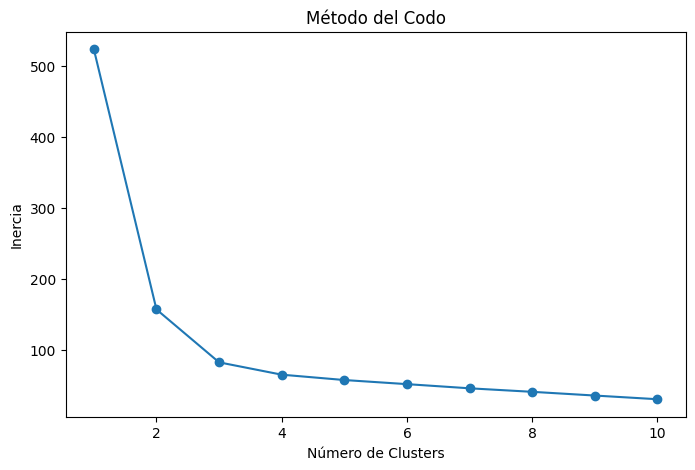

In [ ]:
import matplotlib.pyplot as plt

# 8. GRÁFICO DEL CODO
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inercias,
    marker="o"
)

plt.title("Método del Codo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")

plt.show()

In [ ]:
# =====================================================
# 9. APLICAR K-MEANS
# =====================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(datos_escalados)

In [ ]:
# =====================================================
# 10. AGREGAR CLUSTER AL DATASET
# =====================================================

df["Cluster"] = clusters

In [ ]:
# =====================================================
# 11. MOSTRAR RESULTADOS
# =====================================================

print("\nDataset con clusters:")
print(df.head())

print("\nCantidad de registros por cluster:")
print(df["Cluster"].value_counts())

# =====================================================
# 12. PROMEDIOS POR CLUSTER
# =====================================================

print("\nPromedio por cluster:")
print(df.groupby("Cluster").mean(numeric_only=True))


Dataset con clusters:
  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     I-R0155    41      1855            8.60          192.15          8.53   
1     I-R0116    33       994            6.04           62.84          9.40   
2     I-R0233    43       807            2.94           73.22          4.81   
3     I-R0167    52      1528            9.44          157.53          7.15   
4     I-R0108    27      1169            6.04           92.08          7.97   

   reclamos  antiguedad_meses  Cluster  
0         1                52        1  
1         1                18        0  
2         3                12        2  
3        12                54        1  
4         1                 7        0  

Cantidad de registros por cluster:
Cluster
2    105
0     94
1     63
Name: count, dtype: int64

Promedio por cluster:
              edad     ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
Cluster                                                

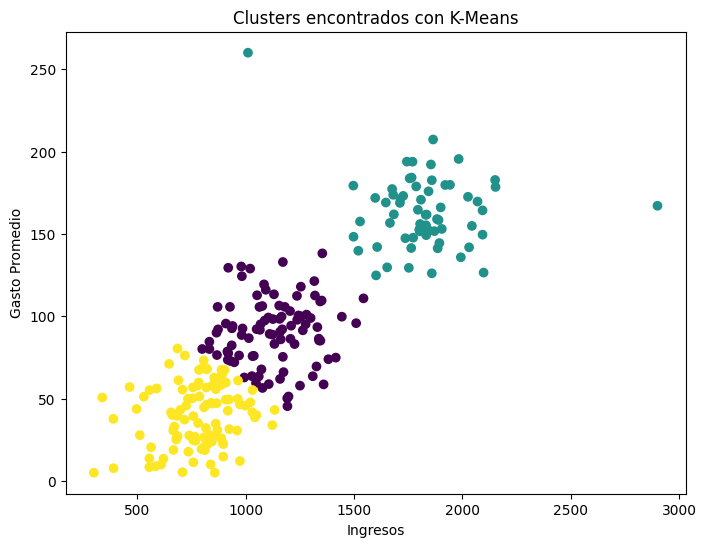

In [ ]:

# =====================================================
# 13. VISUALIZAR CLUSTERS
# =====================================================

plt.figure(figsize=(8,6))

plt.scatter(
    df["ingresos"],
    df["gasto_promedio"],
    c=df["Cluster"]
)

plt.xlabel("Ingresos")
plt.ylabel("Gasto Promedio")

plt.title("Clusters encontrados con K-Means")

plt.show()

### Distribución de Edad por Cluster

Este gráfico de violín muestra la distribución de la edad de los clientes en cada cluster. Podemos observar cómo la edad varía significativamente entre los clusters, apoyando la interpretación de que algunos clusters representan grupos de edad específicos.

In [ ]:
# =====================================================
# 14. GUARDAR DATASET FINAL
# =====================================================

df.to_csv(
    "dataset_final_clusters.csv",
    index=False
)

print("\nDataset guardado correctamente.")


Dataset guardado correctamente.
